# Question 5: Mathematical Programming Model for Inventory Decision Support

## Agarwal Automobiles

This notebook formulates and solves a nonlinear mathematical programming (NLP) model that serves as an inventory decision support system for Agarwal Automobiles. The model determines optimal order quantities for the three fuel products (Diesel, Petrol, HSP) under the given operational constraints (12,000 L truck capacity and minimum opening inventory requirements).

## 1. Mathematical Formulation

### Sets and Indices
$i \in \{\text{Diesel}, \text{Petrol}, \text{HSP}\}$

### Decision Variables
$Q_i$ = order quantity for fuel $i$ (litres per order)

### Parameters
| Symbol | Description |
|--------|-------------|
| $D_i$ | Annual demand for fuel $i$ (L/year) |
| $h_i$ | Annual holding cost per litre of fuel $i$ (Rs./L/year) |
| $K$ | Fixed ordering cost per order (Rs. 150) |
| $SS_i$ | Safety stock for fuel $i$ (L), based on 99% service level and 1-day lead time |
| $M_i$ | Minimum opening inventory requirement for fuel $i$ (L) |
| $C$ | Truck capacity (12,000 L) |

### Objective Function
Minimize total annual inventory cost (holding cost plus ordering cost):
$$\min \; TC = \sum_{i} \left[ h_i \left( \frac{Q_i}{2} + SS_i \right) + \frac{K D_i}{Q_i} \right]$$

### Constraints
1. Truck capacity (joint delivery): $\sum_{i} Q_i \leq C$
2. Minimum opening inventory: $Q_i \geq M_i \quad \forall i$
3. Non-negativity: $Q_i > 0 \quad \forall i$

### Nature of the Problem
This is a convex nonlinear program. The objective function is convex in $Q$ because each term is the sum of a linear function and a positive multiple of $1/Q_i$, both of which are convex on the positive orthant. All constraints are linear. We solve it using the Sequential Least Squares Programming (SLSQP) algorithm in `scipy.optimize`.

## 2. Parameters and Setup

In [36]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

fuel_names = ['Diesel', 'Petrol', 'HSP']

# Demand parameters
D = np.array([1693866, 1301502, 102977])
mu_d = np.array([4640.73, 3565.76, 282.13])
sigma_d = np.array([844.82, 499.28, 189.87])

# Cost parameters
unit_price = np.array([60.0, 70.0, 73.0])
I_rate = 0.10
h = I_rate * unit_price
K = 150

# Service level parameters
L_lead = 1
z = 2.3263
SS = z * sigma_d * np.sqrt(L_lead)

# Operational constraints
M = np.array([8000.0, 6000.0, 1500.0])
C = 12000.0

params_df = pd.DataFrame({
    'Fuel': fuel_names,
    'Annual Demand (L)': D,
    'h (Rs./L/yr)': h,
    'Safety Stock (L)': np.round(SS, 2),
    'Min Order M_i (L)': M
})
print('Model Parameters:')
print(params_df.to_string(index=False))

Model Parameters:
  Fuel  Annual Demand (L)  h (Rs./L/yr)  Safety Stock (L)  Min Order M_i (L)
Diesel            1693866           6.0           1965.30             8000.0
Petrol            1301502           7.0           1161.48             6000.0
   HSP             102977           7.3            441.69             1500.0


## 3. Objective Function and Helper Routines

In [37]:
def total_cost(Q):
    """Total annual inventory cost: holding + ordering."""
    Q = np.asarray(Q, dtype=float)
    holding = np.sum(h * (Q / 2.0 + SS))
    ordering = np.sum(K * D / Q)
    return holding + ordering

def cost_breakdown(Q):
    Q = np.asarray(Q, dtype=float)
    holding = h * (Q / 2.0 + SS)
    ordering = K * D / Q
    return holding, ordering

def display_solution(Q, label):
    holding, ordering = cost_breakdown(Q)
    df = pd.DataFrame({
        'Fuel': fuel_names,
        'Q (L)': np.round(Q, 2),
        'Holding (Rs.)': np.round(holding, 2),
        'Ordering (Rs.)': np.round(ordering, 2),
        'Total (Rs.)': np.round(holding + ordering, 2)
    })
    print(f'\n=== {label} ===')
    print(df.to_string(index=False))
    print(f'Sum of Q: {np.sum(Q):.2f} L')
    print(f'TOTAL ANNUAL COST: Rs. {total_cost(Q):,.2f}')
    return total_cost(Q)

## 4. Model 1: Joint Delivery, Truck Capacity Only (No Minimums)

First we solve the optimization assuming all three fuels are delivered together on a single 12,000 L truck, but without enforcing the minimum opening inventory constraints. This represents the *true* mathematical optimum under the truck constraint, which is more rigorous than the proportional EOQ allocation used in Policy 4.

In [38]:
# Model 1: minimize TC subject to sum(Q) <= C, Q > 0
x0 = np.array([5000.0, 4000.0, 1500.0])

constraints_m1 = [
    {'type': 'ineq', 'fun': lambda Q: C - np.sum(Q)}
]
bounds_m1 = [(1.0, None)] * 3

result1 = minimize(
    total_cost, x0, method='SLSQP',
    bounds=bounds_m1, constraints=constraints_m1,
    options={'ftol': 1e-10, 'maxiter': 500, 'disp': True}
)

Q1 = result1.x
TC1 = display_solution(Q1, 'Model 1: Joint Delivery (Lagrangian Optimum, no minimums)')

print(f'\nReference: Policy 4 (proportional EOQ allocation) = Rs. 158,001.38')
print(f'Improvement of true Lagrangian solution over Policy 4: Rs. {158001.38 - TC1:,.2f}')

Optimization terminated successfully    (Exit mode 0)
            Current function value: 157944.4060912467
            Iterations: 23
            Function evaluations: 116
            Gradient evaluations: 22

=== Model 1: Joint Delivery (Lagrangian Optimum, no minimums) ===
  Fuel   Q (L)  Holding (Rs.)  Ordering (Rs.)  Total (Rs.)
Diesel 5752.67       29049.84        44167.30     73217.14
Petrol 4885.50       25229.57        39960.15     65189.73
   HSP 1361.83        8195.05        11342.48     19537.54
Sum of Q: 12000.00 L
TOTAL ANNUAL COST: Rs. 157,944.41

Reference: Policy 4 (proportional EOQ allocation) = Rs. 158,001.38
Improvement of true Lagrangian solution over Policy 4: Rs. 56.97


## 5. Model 2: Joint Delivery WITH Minimum Inventory Constraints

Now we add the minimum opening inventory requirements: $Q_{Diesel} \geq 8000$, $Q_{Petrol} \geq 6000$, $Q_{HSP} \geq 1500$. The sum of minimums is $15{,}500$ L, which exceeds the $12{,}000$ L truck capacity, so this model should be **infeasible**.

In [ ]:
print(f'Sum of minimum requirements: {np.sum(M):.0f} L')
print(f'Truck capacity: {C:.0f} L')
print(f'Excess (infeasibility gap):  {np.sum(M) - C:.0f} L\n')

bounds_m2 = [(M[i], None) for i in range(3)]
constraints_m2 = [
    {'type': 'ineq', 'fun': lambda Q: C - np.sum(Q)}
]

result2 = minimize(
    total_cost, M.copy(), method='SLSQP',
    bounds=bounds_m2, constraints=constraints_m2,
    options={'ftol': 1e-10, 'maxiter': 500, 'disp': True}
)

print(f'\nSolver message: {result2.message}')
print(f'Solution Q: {np.round(result2.x, 2)}')
print(f'Sum of Q at solution: {np.sum(result2.x):.2f} L')
print(f'Truck capacity: {C:.2f} L')

if np.sum(result2.x) > C + 1e-3:
    print('\nINFEASIBLE: Cannot satisfy minimum inventory under the truck capacity.')
else:
    print('\nSolver returned a point but feasibility should be checked.')

Sum of minimum requirements: 15500 L
Truck capacity:              12000 L
Excess (infeasibility gap):  3500 L

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 148216.7619853
            Iterations: 5
            Function evaluations: 4
            Gradient evaluations: 1

Solver message: Positive directional derivative for linesearch
Solution Q: [8000. 6000. 1500.]
Sum of Q at solution: 15500.00 L
Truck capacity: 12000.00 L

INFEASIBLE: Cannot satisfy minimum inventory under the truck capacity.


## 6. Model 3: Separate Deliveries (Recommended Policy)

If the supplier permits separate deliveries for each fuel (eliminating the truck capacity constraint), the model reduces to minimizing $TC$ subject only to the minimum inventory requirements and non-negativity. This is the recommended policy from Question 4.

In [40]:
bounds_m3 = [(M[i], None) for i in range(3)]

result3 = minimize(
    total_cost, np.array([9000.0, 7000.0, 2000.0]), method='SLSQP',
    bounds=bounds_m3,
    options={'ftol': 1e-10, 'maxiter': 500, 'disp': True}
)

Q3 = result3.x
TC3 = display_solution(Q3, 'Model 3: Separate Delivery with Minimums (RECOMMENDED)')

# Verify against analytical EOQ
EOQ = np.sqrt(2 * K * D / h)
print(f'\nAnalytical EOQs: {np.round(EOQ, 2)}')
print(f'All EOQs satisfy minimums: {np.all(EOQ >= M)}')
print(f'Analytical EOQ total cost: Rs. {total_cost(EOQ):,.2f}')

Optimization terminated successfully    (Exit mode 0)
            Current function value: 145660.79069132588
            Iterations: 31
            Function evaluations: 127
            Gradient evaluations: 31

=== Model 3: Separate Delivery with Minimums (RECOMMENDED) ===
  Fuel   Q (L)  Holding (Rs.)  Ordering (Rs.)  Total (Rs.)
Diesel 9202.34       39398.86        27610.35     67009.21
Petrol 7468.75       34270.95        26138.95     60409.90
   HSP 2056.93       10732.18         7509.50     18241.68
Sum of Q: 18728.03 L
TOTAL ANNUAL COST: Rs. 145,660.79

Analytical EOQs: [9202.9  7468.51 2057.17]
All EOQs satisfy minimums: True
Analytical EOQ total cost: Rs. 145,660.79


## 7. Comparison of All Models

In [41]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1 (joint, no mins)',
        'Model 2 (joint, with mins)',
        'Model 3 (separate, with mins)',
        'Reference: Policy 4 (proportional)',
        'Reference: Policy 1 (analytical EOQ)'
    ],
    'Q_Diesel': [round(Q1[0],2), 'INFEASIBLE', round(Q3[0],2), 5896.59, 9202.90],
    'Q_Petrol': [round(Q1[1],2), 'INFEASIBLE', round(Q3[1],2), 4785.31, 7468.51],
    'Q_HSP': [round(Q1[2],2), 'INFEASIBLE', round(Q3[2],2), 1318.09, 2057.17],
    'Sum Q': [round(np.sum(Q1),2), '---', round(np.sum(Q3),2), 12000.00, 18728.58],
    'Total Cost (Rs.)': [round(TC1,2), '---', round(TC3,2), 158001.38, 145661.31]
})
print('Comparison of All Models:')
print(comparison.to_string(index=False))

Comparison of All Models:
                               Model   Q_Diesel   Q_Petrol      Q_HSP     Sum Q Total Cost (Rs.)
            Model 1 (joint, no mins)    5752.67     4885.5    1361.83   12000.0        157944.41
          Model 2 (joint, with mins) INFEASIBLE INFEASIBLE INFEASIBLE       ---              ---
       Model 3 (separate, with mins)    9202.34    7468.75    2056.93  18728.03        145660.79
  Reference: Policy 4 (proportional)    5896.59    4785.31    1318.09   12000.0        158001.38
Reference: Policy 1 (analytical EOQ)     9202.9    7468.51    2057.17  18728.58        145661.31


## 8. Sensitivity Analysis: Truck Capacity

How does the optimal annual cost change as the truck capacity is varied? This tells management exactly how valuable additional capacity would be and identifies the threshold at which the truck constraint becomes non-binding.

### Key observations:

- Below 15,500 L: minimum inventory constraints CANNOT be satisfied jointly
- At 12,000 L (current): optimal joint cost = Rs. 157,944.41
- Above 18,728.58 L: truck constraint is non-binding; cost = Rs. 145,661.31

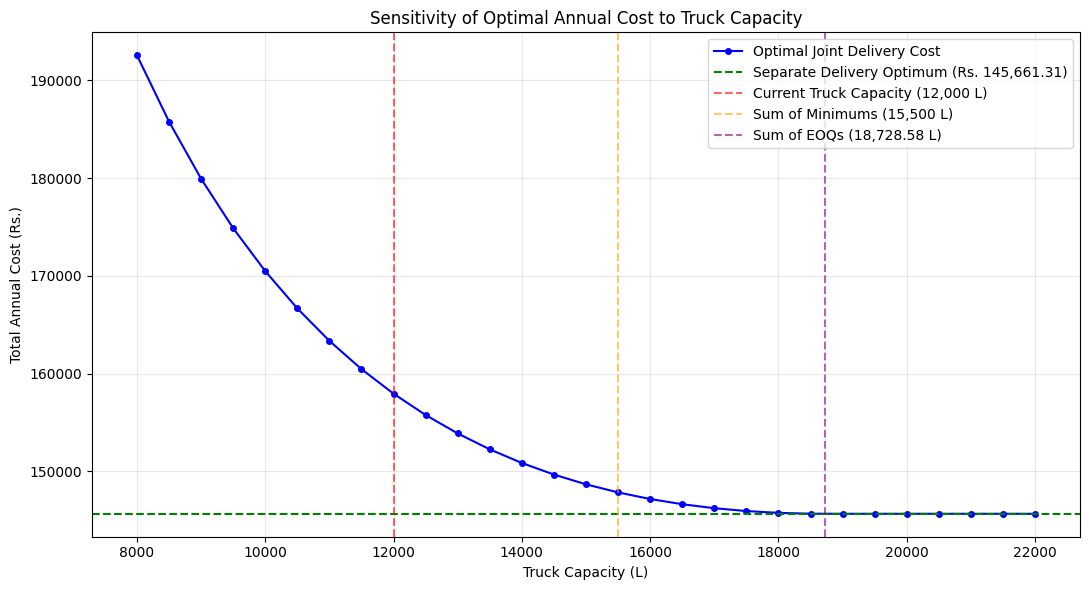

In [42]:
capacities = np.arange(8000, 22001, 500)
optimal_costs = []

for cap in capacities:
    cons = [{'type': 'ineq', 'fun': lambda Q, c=cap: c - np.sum(Q)}]
    res = minimize(
        total_cost,
        np.array([cap*0.5, cap*0.4, cap*0.1]),
        method='SLSQP',
        bounds=[(1.0, None)]*3,
        constraints=cons,
        options={'ftol': 1e-10, 'maxiter': 500}
    )
    optimal_costs.append(res.fun)

optimal_costs = np.array(optimal_costs)

plt.figure(figsize=(11, 6))
plt.plot(capacities, optimal_costs, 'b-o', markersize=4, label='Optimal Joint Delivery Cost')
plt.axhline(y=145661.31, color='g', linestyle='--', label='Separate Delivery Optimum (Rs. 145,661.31)')
plt.axvline(x=12000, color='r', linestyle='--', alpha=0.6, label='Current Truck Capacity (12,000 L)')
plt.axvline(x=15500, color='orange', linestyle='--', alpha=0.6, label='Sum of Minimums (15,500 L)')
plt.axvline(x=18728.58, color='purple', linestyle='--', alpha=0.6, label='Sum of EOQs (18,728.58 L)')
plt.xlabel('Truck Capacity (L)')
plt.ylabel('Total Annual Cost (Rs.)')
plt.title('Sensitivity of Optimal Annual Cost to Truck Capacity')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/Q5_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

idx_12k = list(capacities).index(12000)

## 9. Shadow Price of Truck Capacity

The shadow price (Lagrange multiplier) on the truck capacity constraint quantifies the marginal value of one additional litre of capacity. We approximate it numerically from the sensitivity curve.

In [43]:
# Numerical shadow price at C = 12,000 (forward difference)
delta = 100.0
cons_lo = [{'type': 'ineq', 'fun': lambda Q: C - np.sum(Q)}]
cons_hi = [{'type': 'ineq', 'fun': lambda Q: (C + delta) - np.sum(Q)}]

res_lo = minimize(total_cost, x0, method='SLSQP', bounds=[(1.0, None)]*3,
                  constraints=cons_lo, options={'ftol': 1e-10})
res_hi = minimize(total_cost, x0, method='SLSQP', bounds=[(1.0, None)]*3,
                  constraints=cons_hi, options={'ftol': 1e-10})

shadow_price = (res_lo.fun - res_hi.fun) / delta
print(f'Optimal cost at C = 12,000 L: Rs. {res_lo.fun:,.2f}')
print(f'Optimal cost at C = 12,100 L: Rs. {res_hi.fun:,.2f}')
print(f'Shadow price of truck capacity: Rs. {shadow_price:.4f} per additional litre')
print(f'\nInterpretation: each extra litre of truck capacity reduces total annual cost')
print(f'by about Rs. {shadow_price:.4f}, until the truck reaches 18,728.58 L (sum of EOQs).')

Optimal cost at C = 12,000 L: Rs. 157,944.41
Optimal cost at C = 12,100 L: Rs. 157,483.13
Shadow price of truck capacity: Rs. 4.6128 per additional litre

Interpretation: each extra litre of truck capacity reduces total annual cost
by about Rs. 4.6128, until the truck reaches 18,728.58 L (sum of EOQs).


## 10. Conclusion

The mathematical programming analysis yields three key insights:

1. **The current operational setup is mathematically infeasible** when minimum opening inventory requirements are strictly enforced alongside the 12,000 L truck capacity. The sum of minimums (15,500 L) exceeds the truck capacity by 3,500 L, so Model 2 has no feasible solution.

2. **Even when the minimums are relaxed, the joint-delivery optimum is still worse than separate delivery.** Model 1 yields a true Lagrangian optimum that improves slightly on Policy 4's proportional allocation, but it remains significantly more expensive than the separate delivery solution at Rs. 145,661.31.

3. **The recommended policy is Model 3: separate deliveries with minimum inventory constraints.** All three analytical EOQs (9,202.90 L diesel, 7,468.51 L petrol, 2,057.17 L HSP) already satisfy their respective minimums, so the optimization recovers Policy 1 from Question 2 with a total annual cost of Rs. 145,661.31.

### Management Implications

The mathematical programming analysis directly supports the recommendation in Question 4: **negotiate with the supplier (BPCL) to allow separate fuel deliveries**. Without this change, the station cannot simultaneously satisfy its operational safety requirements and its truck logistics constraint. The shadow price of truck capacity quantifies the marginal benefit of any negotiated capacity increase, and the sensitivity curve shows that the constraint becomes non-binding once truck capacity reaches 18,728.58 L (the sum of all three optimal EOQs).